# Extraction and Preprocessing 

## What it does: 
Processes raw precise point positioning data from GPS position files to calculate daily ice velocity estimates for the GPS stations. It uses this velcotiy to create a velocity time-series which allows every icequake to have velocity as a feature. 

## Inputs: 
- PPP files 
- Slip event catalog 

## Outputs: 
- Event catalog that gives the pre-event velocity median for each event, the velocity components per station, and how many observations were used 
- Daily velocity time series 

## References: 
- Katz, Z. S., Siegfried, M. R., & Padman, L. (2026). Slip-event timing and ice velocity vary at long-period ocean tidal frequencies at Whillans Ice Plain, West Antarctica. Journal of Geophysical Research: Earth Surface, 131, e2025JF008770. https://doi.org/10.1029/2025JF008770
- https://zenodo.org/records/17797751 
- https://github.com/zsk4/WhillansCatalogPaper/releases/tag/v1.2.1 



Loaded: 31,662 station-days | 48 stations | 2007-12-02 to 2017-12-31


/tmp/ipykernel_32053/1460566134.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Figure 1 saved -> figure1_data_coverage.png


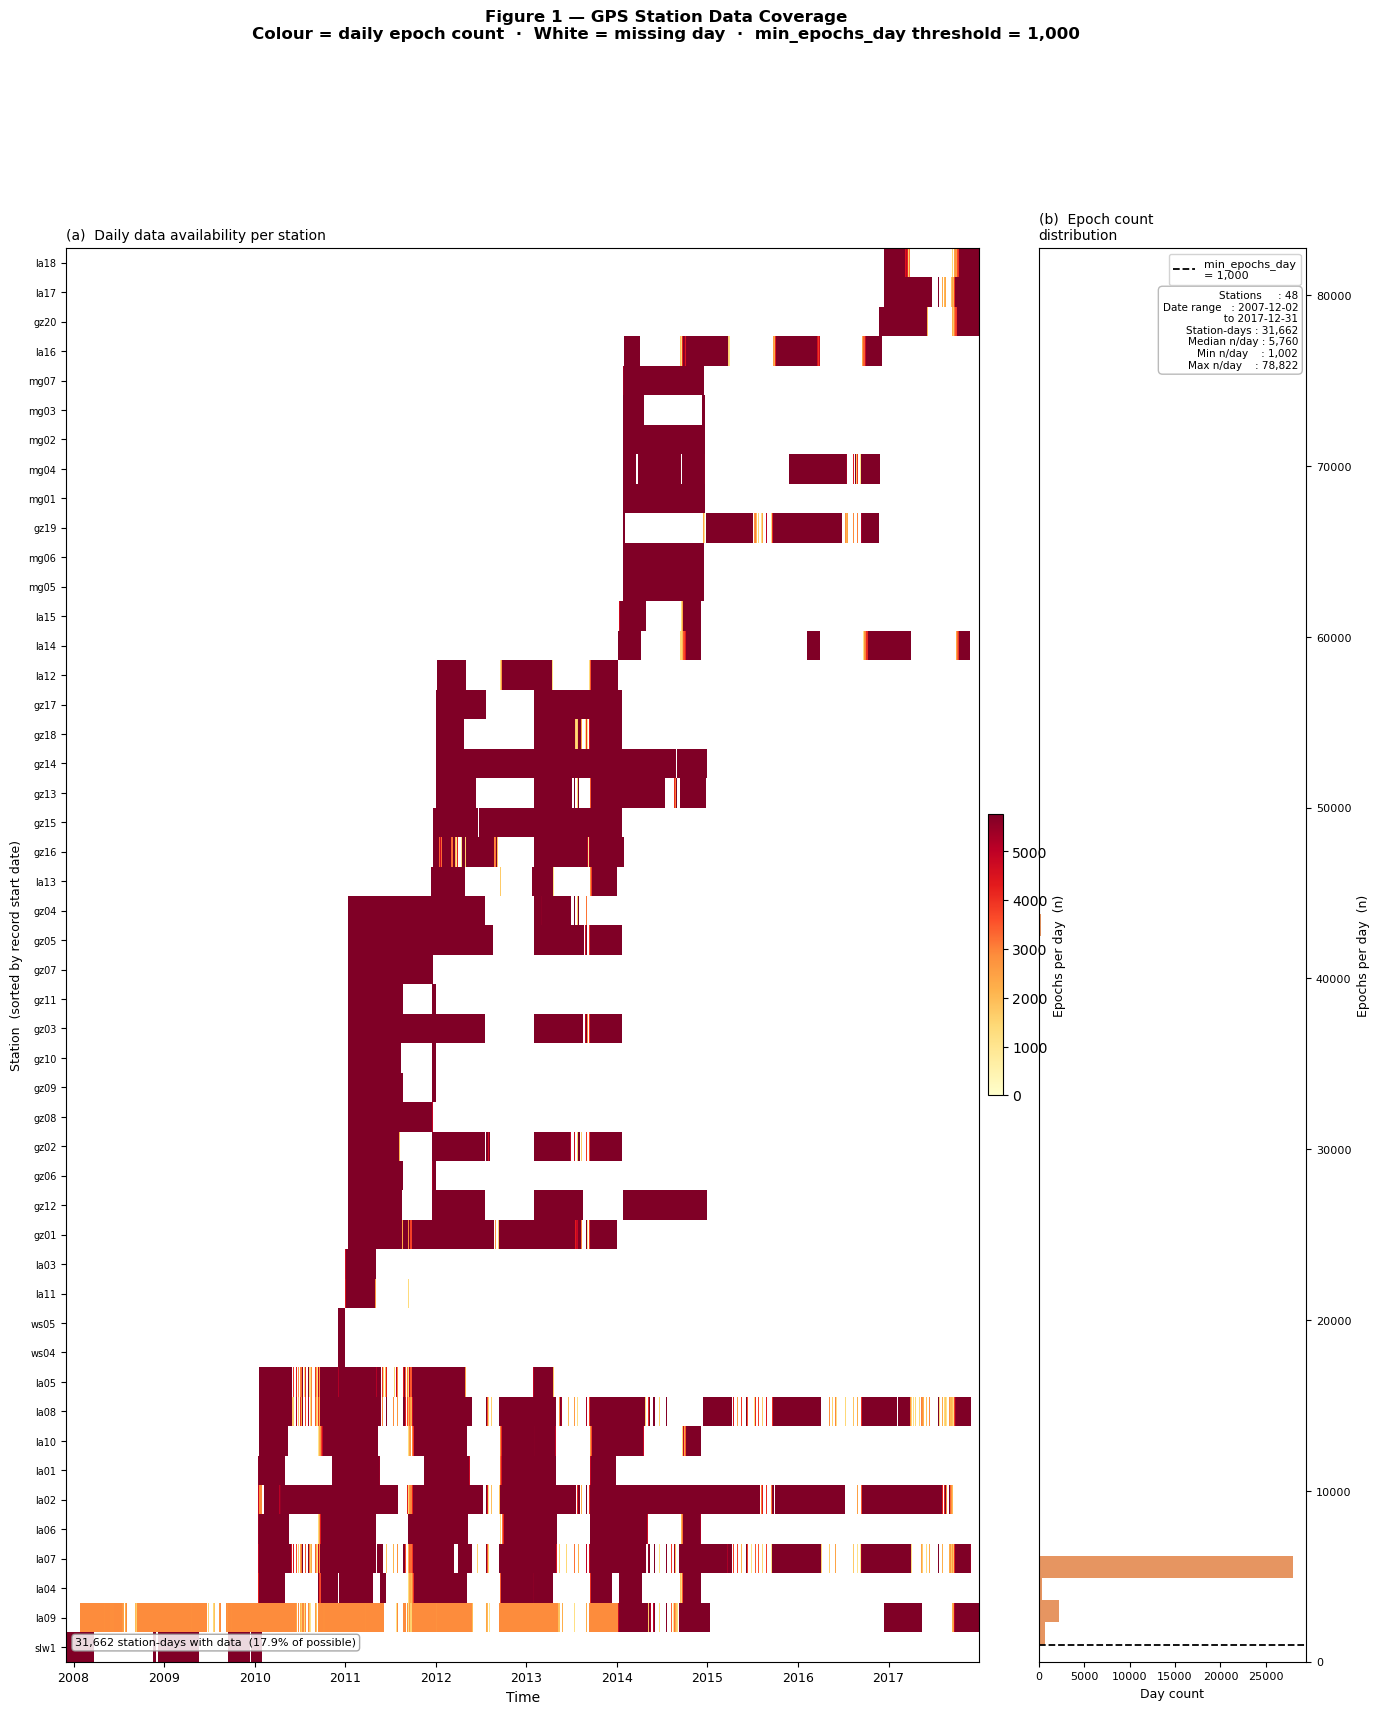

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── Config ────────────────────────────────────────────────────────────────────
Daily_timeseries_csv = "../Data/ppp_velocity_timeseries.csv"
min_epochs_day       = 1000   # must match pipeline constant
out_path             = "figure1_data_coverage.png"

# ── Load ──────────────────────────────────────────────────────────────────────
full_ts = pd.read_csv(Daily_timeseries_csv, parse_dates=["timestamp"])
print(f"Loaded: {len(full_ts):,} station-days | "
      f"{full_ts['station'].nunique()} stations | "
      f"{full_ts['timestamp'].min().date()} to {full_ts['timestamp'].max().date()}")

# ── Station order: earliest record start at top ───────────────────────────────
stn_order = (full_ts.groupby("station")["timestamp"]
             .min().sort_values().index.tolist())
n_stns  = len(stn_order)
stn_idx = {s: i for i, s in enumerate(stn_order)}

# ── Regular daily time grid ───────────────────────────────────────────────────
t_min   = full_ts["timestamp"].min().normalize()
t_max   = full_ts["timestamp"].max().normalize()
t_grid  = pd.date_range(t_min, t_max, freq="D")
n_days  = len(t_grid)
day_idx = {t: i for i, t in enumerate(t_grid)}

# ── 2-D epoch-count matrix (NaN = missing day) ────────────────────────────────
epoch_matrix = np.full((n_stns, n_days), np.nan)
for _, row in full_ts.iterrows():
    r = stn_idx.get(row["station"])
    c = day_idx.get(row["timestamp"].normalize())
    if r is not None and c is not None:
        epoch_matrix[r, c] = row["n"]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, max(6, n_stns * 0.32 + 3)))
fig.suptitle(
    "Figure 1 — GPS Station Data Coverage\n"
    f"Colour = daily epoch count  ·  White = missing day  ·  "
    f"min_epochs_day threshold = {min_epochs_day:,}",
    fontsize=12, fontweight="bold", y=1.01
)

gs     = GridSpec(1, 2, figure=fig, width_ratios=[3.5, 1], wspace=0.06)
ax_hm  = fig.add_subplot(gs[0])
ax_his = fig.add_subplot(gs[1])

# ── (a) Heatmap ───────────────────────────────────────────────────────────────
cmap = plt.get_cmap("YlOrRd").copy()
cmap.set_bad(color="white")          # NaN (missing days) render as white
masked = np.ma.masked_invalid(epoch_matrix)
vmax   = np.nanpercentile(epoch_matrix[~np.isnan(epoch_matrix)], 98)

pcm = ax_hm.pcolormesh(
    np.arange(n_days + 1), np.arange(n_stns + 1),
    masked, cmap=cmap, vmin=0, vmax=vmax, shading="flat"
)

# x-axis: year ticks
year_ticks, year_labels = [], []
for yr in range(t_min.year, t_max.year + 2):
    t_yr = pd.Timestamp(f"{yr}-01-01").normalize()
    if t_yr in day_idx:
        year_ticks.append(day_idx[t_yr])
        year_labels.append(str(yr))
ax_hm.set_xticks(year_ticks)
ax_hm.set_xticklabels(year_labels, fontsize=9)
ax_hm.set_xlim(0, n_days)

# y-axis: station names
ax_hm.set_yticks(np.arange(n_stns) + 0.5)
ax_hm.set_yticklabels(stn_order, fontsize=7)
ax_hm.set_ylim(0, n_stns)

ax_hm.set_xlabel("Time", fontsize=10)
ax_hm.set_ylabel("Station  (sorted by record start date)", fontsize=9)
ax_hm.set_title("(a)  Daily data availability per station", fontsize=10, loc="left")

cb = fig.colorbar(pcm, ax=ax_hm, fraction=0.015, pad=0.01)
cb.set_label("Epochs per day  (n)", fontsize=9)

# Coverage annotation
total_present = int(np.sum(~np.isnan(epoch_matrix)))
pct_covered   = 100.0 * total_present / (n_stns * n_days)
ax_hm.text(
    0.01, 0.01,
    f"{total_present:,} station-days with data  ({pct_covered:.1f}% of possible)",
    transform=ax_hm.transAxes, fontsize=8, va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="0.6", alpha=0.85)
)

# ── (b) Epoch-count histogram ─────────────────────────────────────────────────
n_vals = full_ts["n"].dropna().values

ax_his.hist(n_vals, bins=60, orientation="horizontal",
            color="#e07b39", alpha=0.8, edgecolor="none")
ax_his.axhline(min_epochs_day, color="black", linewidth=1.3,
               linestyle="--", zorder=3,
               label=f"min_epochs_day\n= {min_epochs_day:,}")

ax_his.set_xlabel("Day count", fontsize=9)
ax_his.set_ylabel("Epochs per day  (n)", fontsize=9)
ax_his.set_title("(b)  Epoch count\ndistribution", fontsize=10, loc="left")
ax_his.tick_params(labelsize=8)
ax_his.set_ylim(0, n_vals.max() * 1.05)
ax_his.yaxis.set_label_position("right")
ax_his.yaxis.tick_right()
ax_his.legend(fontsize=8, loc="upper right", framealpha=0.85)

stats_txt = (
    f"Stations     : {n_stns}\n"
    f"Date range   : {t_min.date()}\n"
    f"               to {t_max.date()}\n"
    f"Station-days : {total_present:,}\n"
    f"Median n/day : {int(np.median(n_vals)):,}\n"
    f"Min n/day    : {int(n_vals.min()):,}\n"
    f"Max n/day    : {int(n_vals.max()):,}"
)
ax_his.text(
    0.97, 0.97, stats_txt,
    transform=ax_his.transAxes, fontsize=7.5, va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
              edgecolor="0.7", alpha=0.9)
)

fig.tight_layout()
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Figure 1 saved -> {out_path}")
plt.show()

Loaded: 31,662 station-days | 48 stations | 2007-12-02 to 2017-12-31


/tmp/ipykernel_32053/337076237.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


Figure 1 saved -> figure1_data_coverage.png


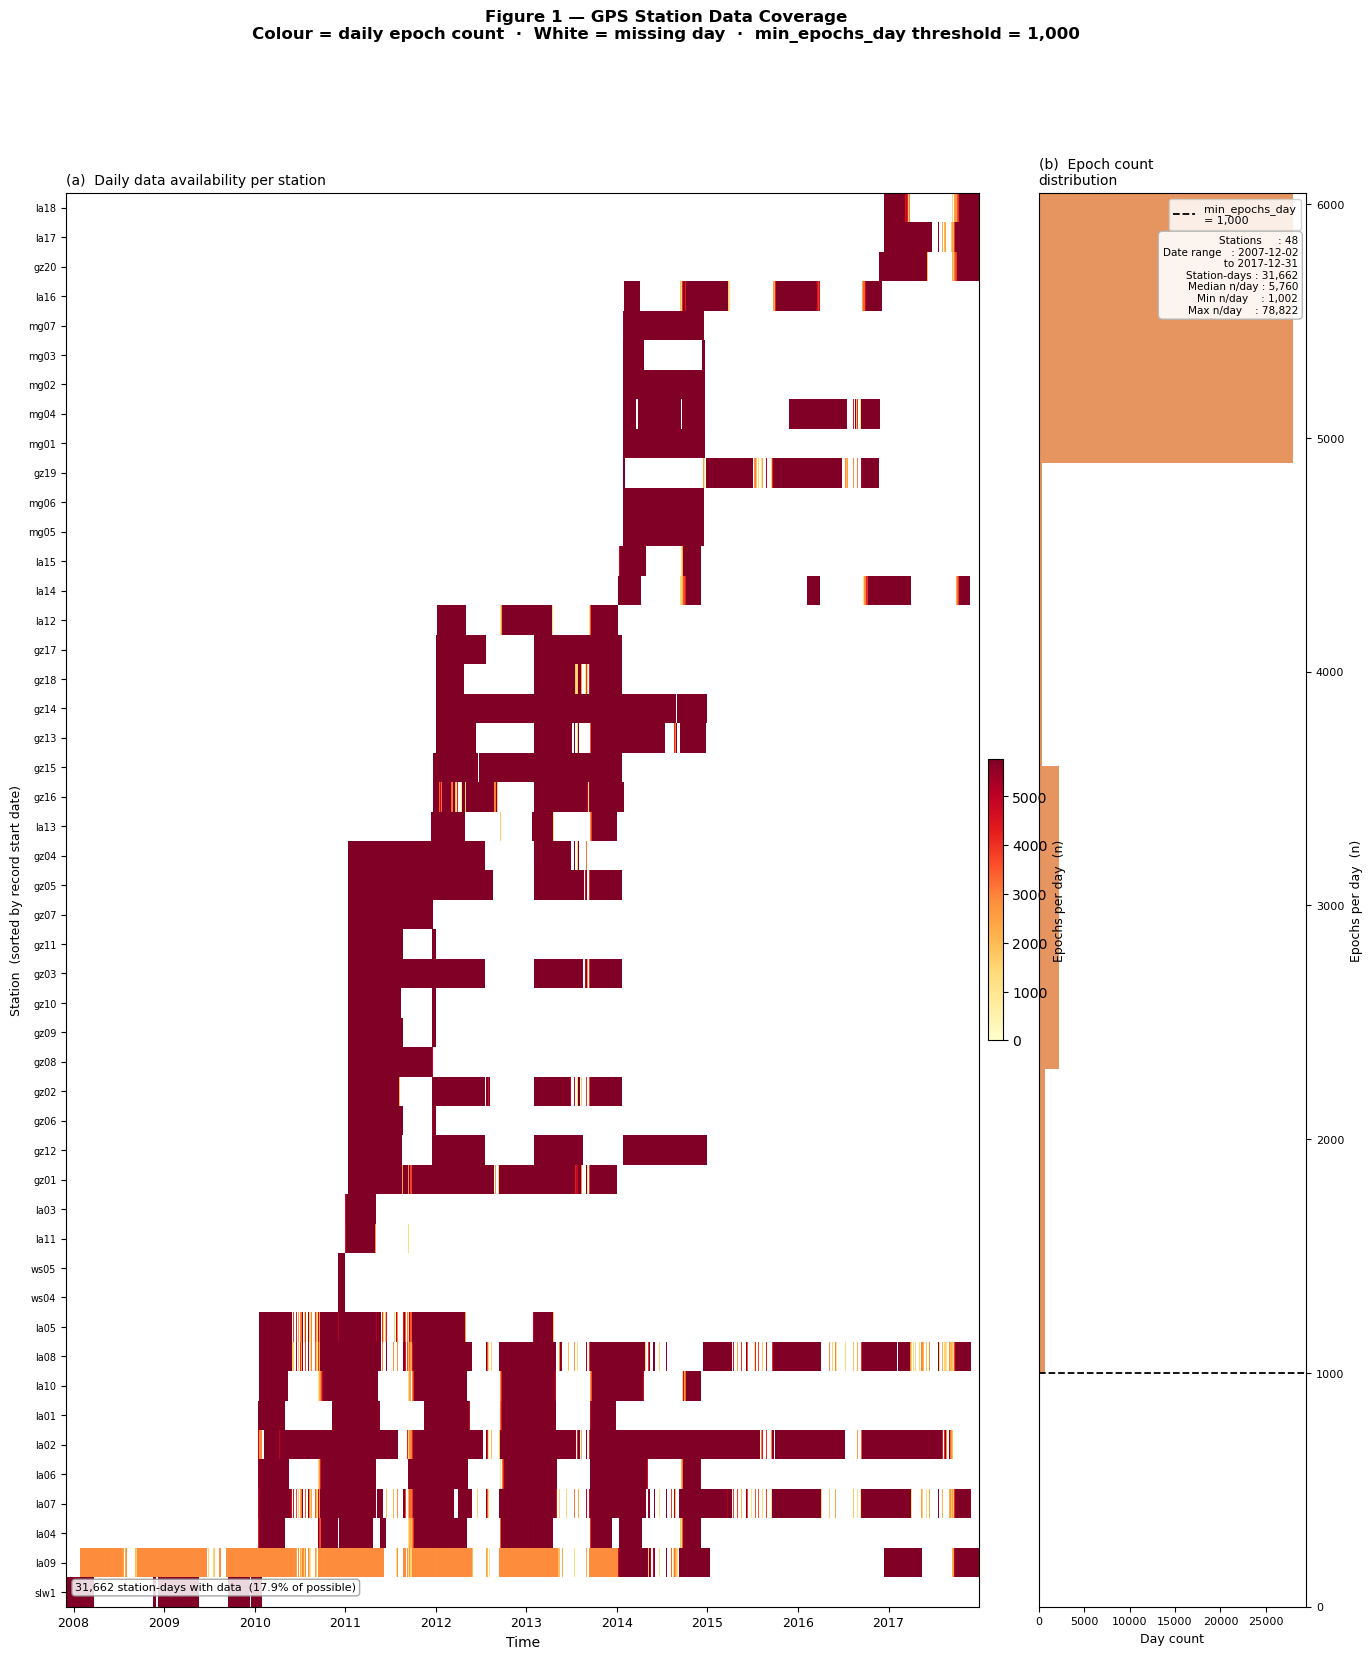

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ── Config ────────────────────────────────────────────────────────────────────
Daily_timeseries_csv = "../Data/ppp_velocity_timeseries.csv"
min_epochs_day       = 1000   # must match pipeline constant
out_path             = "figure1_data_coverage.png"

# ── Load ──────────────────────────────────────────────────────────────────────
full_ts = pd.read_csv(Daily_timeseries_csv, parse_dates=["timestamp"])
print(f"Loaded: {len(full_ts):,} station-days | "
      f"{full_ts['station'].nunique()} stations | "
      f"{full_ts['timestamp'].min().date()} to {full_ts['timestamp'].max().date()}")

# ── Station order: earliest record start at top ───────────────────────────────
stn_order = (full_ts.groupby("station")["timestamp"]
             .min().sort_values().index.tolist())
n_stns  = len(stn_order)
stn_idx = {s: i for i, s in enumerate(stn_order)}

# ── Regular daily time grid ───────────────────────────────────────────────────
t_min   = full_ts["timestamp"].min().normalize()
t_max   = full_ts["timestamp"].max().normalize()
t_grid  = pd.date_range(t_min, t_max, freq="D")
n_days  = len(t_grid)
day_idx = {t: i for i, t in enumerate(t_grid)}

# ── 2-D epoch-count matrix (NaN = missing day) ────────────────────────────────
epoch_matrix = np.full((n_stns, n_days), np.nan)
for _, row in full_ts.iterrows():
    r = stn_idx.get(row["station"])
    c = day_idx.get(row["timestamp"].normalize())
    if r is not None and c is not None:
        epoch_matrix[r, c] = row["n"]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, max(6, n_stns * 0.32 + 3)))
fig.suptitle(
    "Figure 1 — GPS Station Data Coverage\n"
    f"Colour = daily epoch count  ·  White = missing day  ·  "
    f"min_epochs_day threshold = {min_epochs_day:,}",
    fontsize=12, fontweight="bold", y=0.98
)

gs     = GridSpec(1, 2, figure=fig, width_ratios=[3.5, 1], wspace=0.06)
ax_hm  = fig.add_subplot(gs[0])
ax_his = fig.add_subplot(gs[1])

# ── (a) Heatmap ───────────────────────────────────────────────────────────────
cmap = plt.get_cmap("YlOrRd").copy()
cmap.set_bad(color="white")          # NaN (missing days) render as white
masked = np.ma.masked_invalid(epoch_matrix)
vmax = 5760   # one complete day of 15-sec epochs — hard cap so outliers don't wreck the scale

pcm = ax_hm.pcolormesh(
    np.arange(n_days + 1), np.arange(n_stns + 1),
    masked, cmap=cmap, vmin=0, vmax=vmax, shading="flat"
)

# x-axis: year ticks
year_ticks, year_labels = [], []
for yr in range(t_min.year, t_max.year + 2):
    t_yr = pd.Timestamp(f"{yr}-01-01").normalize()
    if t_yr in day_idx:
        year_ticks.append(day_idx[t_yr])
        year_labels.append(str(yr))
ax_hm.set_xticks(year_ticks)
ax_hm.set_xticklabels(year_labels, fontsize=9)
ax_hm.set_xlim(0, n_days)

# y-axis: station names
ax_hm.set_yticks(np.arange(n_stns) + 0.5)
ax_hm.set_yticklabels(stn_order, fontsize=7)
ax_hm.set_ylim(0, n_stns)

ax_hm.set_xlabel("Time", fontsize=10)
ax_hm.set_ylabel("Station  (sorted by record start date)", fontsize=9)
ax_hm.set_title("(a)  Daily data availability per station", fontsize=10, loc="left")

cb = fig.colorbar(pcm, ax=ax_hm, fraction=0.015, pad=0.01)
cb.set_label("Epochs per day  (n)", fontsize=9)

# Coverage annotation
total_present = int(np.sum(~np.isnan(epoch_matrix)))
pct_covered   = 100.0 * total_present / (n_stns * n_days)
ax_hm.text(
    0.01, 0.01,
    f"{total_present:,} station-days with data  ({pct_covered:.1f}% of possible)",
    transform=ax_hm.transAxes, fontsize=8, va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="0.6", alpha=0.85)
)

# ── (b) Epoch-count histogram ─────────────────────────────────────────────────
n_vals = full_ts["n"].dropna().values

ax_his.hist(n_vals, bins=60, orientation="horizontal",
            color="#e07b39", alpha=0.8, edgecolor="none")
ax_his.axhline(min_epochs_day, color="black", linewidth=1.3,
               linestyle="--", zorder=3,
               label=f"min_epochs_day\n= {min_epochs_day:,}")

ax_his.set_xlabel("Day count", fontsize=9)
ax_his.set_ylabel("Epochs per day  (n)", fontsize=9)
ax_his.set_title("(b)  Epoch count\ndistribution", fontsize=10, loc="left")
ax_his.tick_params(labelsize=8)
ax_his.set_ylim(0, 5760 * 1.05)   # cap at one full day; outlier stations saturate at top
ax_his.yaxis.set_label_position("right")
ax_his.yaxis.tick_right()
ax_his.legend(fontsize=8, loc="upper right", framealpha=0.85)

stats_txt = (
    f"Stations     : {n_stns}\n"
    f"Date range   : {t_min.date()}\n"
    f"               to {t_max.date()}\n"
    f"Station-days : {total_present:,}\n"
    f"Median n/day : {int(np.median(n_vals)):,}\n"
    f"Min n/day    : {int(n_vals.min()):,}\n"
    f"Max n/day    : {int(n_vals.max()):,}"
)
ax_his.text(
    0.97, 0.97, stats_txt,
    transform=ax_his.transAxes, fontsize=7.5, va="top", ha="right",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
              edgecolor="0.7", alpha=0.9)
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Figure 1 saved -> {out_path}")
plt.show()

Figure 1 saved -> figure1_data_coverage.png


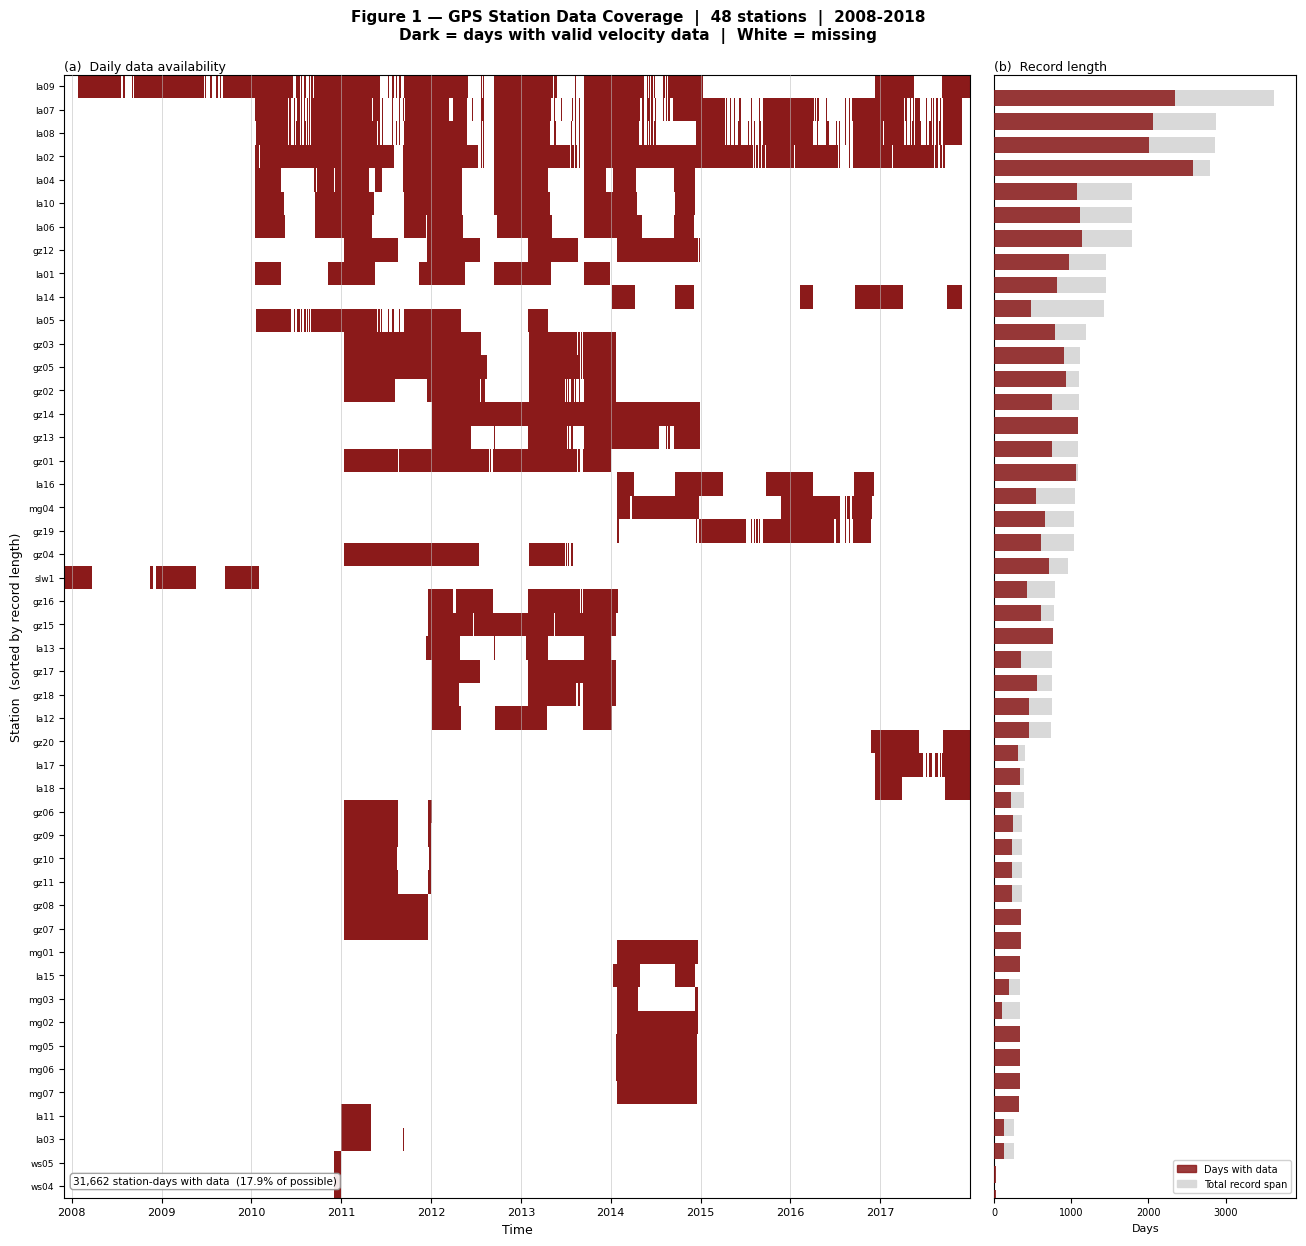

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Config ────────────────────────────────────────────────────────────────────
Daily_timeseries_csv = "../Data/ppp_velocity_timeseries.csv"
out_path             = "figure1_data_coverage.png"

# ── Load ──────────────────────────────────────────────────────────────────────
full_ts = pd.read_csv(Daily_timeseries_csv, parse_dates=["timestamp"])

# ── Station order: longest record at top ──────────────────────────────────────
stn_stats = full_ts.groupby("station")["timestamp"].agg(
    start="min", end="max"
).assign(duration=lambda d: (d["end"] - d["start"]).dt.days)
stn_order = stn_stats["duration"].sort_values(ascending=True).index.tolist()
n_stns    = len(stn_order)
stn_idx   = {s: i for i, s in enumerate(stn_order)}

# ── Daily time grid ───────────────────────────────────────────────────────────
t_min   = full_ts["timestamp"].min().normalize()
t_max   = full_ts["timestamp"].max().normalize()
t_grid  = pd.date_range(t_min, t_max, freq="D")
n_days  = len(t_grid)
day_idx = {t: i for i, t in enumerate(t_grid)}

# ── Binary presence matrix (1 = data, 0 = missing) ───────────────────────────
presence = np.zeros((n_stns, n_days), dtype=np.float32)
full_ts["day_norm"] = full_ts["timestamp"].dt.normalize()
for _, row in full_ts.iterrows():
    r = stn_idx.get(row["station"])
    c = day_idx.get(row["day_norm"])
    if r is not None and c is not None:
        presence[r, c] = 1.0

# ── Figure ────────────────────────────────────────────────────────────────────
row_h = 0.22
fig_h = max(7, n_stns * row_h + 2.5)
fig   = plt.figure(figsize=(14, fig_h))

gs = GridSpec(
    1, 2, figure=fig,
    width_ratios=[3, 1], wspace=0.04,
    left=0.09, right=0.97, top=0.93, bottom=0.07
)
ax_cov = fig.add_subplot(gs[0])
ax_dur = fig.add_subplot(gs[1])

fig.suptitle(
    "Figure 1 — GPS Station Data Coverage  |  48 stations  |  2008-2018\n"
    "Dark = days with valid velocity data  |  White = missing",
    fontsize=11, fontweight="bold", y=0.98
)

# ── (a) Binary coverage heatmap ───────────────────────────────────────────────
from matplotlib.colors import ListedColormap
cmap_bin = ListedColormap(["white", "#8b1a1a"])
ax_cov.pcolormesh(
    np.arange(n_days + 1), np.arange(n_stns + 1),
    presence, cmap=cmap_bin, vmin=0, vmax=1, shading="flat"
)

year_ticks, year_labels = [], []
for yr in range(t_min.year, t_max.year + 2):
    t_yr = pd.Timestamp(f"{yr}-01-01").normalize()
    if t_yr in day_idx:
        xi = day_idx[t_yr]
        year_ticks.append(xi)
        year_labels.append(str(yr))
        ax_cov.axvline(xi, color="0.75", linewidth=0.4, zorder=3)

ax_cov.set_xticks(year_ticks)
ax_cov.set_xticklabels(year_labels, fontsize=8)
ax_cov.set_xlim(0, n_days)
ax_cov.set_yticks(np.arange(n_stns) + 0.5)
ax_cov.set_yticklabels(stn_order, fontsize=6.5)
ax_cov.set_ylim(0, n_stns)
ax_cov.set_xlabel("Time", fontsize=9)
ax_cov.set_ylabel("Station  (sorted by record length)", fontsize=9)
ax_cov.set_title("(a)  Daily data availability", fontsize=9, loc="left", pad=3)

n_present   = int(presence.sum())
pct_present = 100.0 * n_present / (n_stns * n_days)
ax_cov.text(
    0.01, 0.01,
    f"{n_present:,} station-days with data  ({pct_present:.1f}% of possible)",
    transform=ax_cov.transAxes, fontsize=7.5, va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="0.6", alpha=0.9)
)

# ── (b) Record length bar chart ───────────────────────────────────────────────
durations = [stn_stats.loc[s, "duration"] for s in stn_order]
days_data = [int(presence[i].sum()) for i in range(n_stns)]
y_pos     = np.arange(n_stns)

ax_dur.barh(y_pos, durations, height=0.7, color="0.85", zorder=2)
ax_dur.barh(y_pos, days_data, height=0.7, color="#8b1a1a", alpha=0.85, zorder=3)

ax_dur.set_xlabel("Days", fontsize=8)
ax_dur.set_xlim(0, max(durations) * 1.08)
ax_dur.set_yticks([])
ax_dur.set_ylim(0, n_stns)
ax_dur.set_title("(b)  Record length", fontsize=9, loc="left", pad=3)
ax_dur.tick_params(labelsize=7)
ax_dur.xaxis.set_major_locator(plt.MaxNLocator(4, integer=True))

legend_patches = [
    mpatches.Patch(color="#8b1a1a", alpha=0.85, label="Days with data"),
    mpatches.Patch(color="0.85",               label="Total record span"),
]
ax_dur.legend(handles=legend_patches, fontsize=7,
              loc="lower right", framealpha=0.9)

plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Figure 1 saved -> {out_path}")
plt.show()

In [1]:
import os, glob
import numpy as np
import pandas as pd
from pyproj import Transformer

# path configuration 

PPP_dir = "../Data/PPP/PPP/"
Events_csv = "../Data/whillans_velocity_per_event.csv"
Daily_timeseries_csv = "../Data/ppp_velocity_timeseries.csv"
Event_w_vel_csv = "../Data/whillans_events_with_velocity.csv"

#cut offs for preprocessing/filtering the data 

position_threshold = 0.05    # drop any GPS epochs with RMSP > 5 cm
phys_vel_threshold = 2000    # drop computed velocity that is higher than this (physical upper bound for Antarctic ice streams)
sec_per_year = 365.25 * 86400 # converting m/s to m/yr
min_epochs_day = 1000    # setting a limit for how many epochs are needed to give a reasonable median (this is about 17% so a low threshold)
max_day_gap = 2       # max days between consecutive daily estimates
pre_window_days = 30      # days before event to average for pre-event velocity
min_daily_pts = 5       # minimum daily estimates in pre-event window

# Cooridnate Projection
# lat/lon to EPSG:3031 (Antarctic polar sterographic coordinates) so that velocity components are in meters 
geo_to_polar = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)

def proj_geo_to_polar(lat, lon):
    east, north = geo_to_polar.transform(lon, lat)
    return east, north


# Looked at what the columns were using describe in command line to set these 

column_labels = [
    "dir", "frame", "stn", "doy", "date", "time", #direction, reference frame, station ID, day of year, date (yyyy-mm-dd), time
    "nsv", "gdop", "rmsc", "rmsp", # number of satellietes used, geometric effects on precision, RMS of code observations, RMS of phase observations
    "dlat", "dlon", "dhgt", # displacement from reference latitude, longitude and height
    "sdlat", "sdlon", "sdhgt", # 95% confidence for lat, long, and height
    "latdd", "latmn", "latss", # latitude as degrees, minutes, and seconds 
    "londd", "lonmn", "lonss", # longitude as degrees, minutes, and seconds 
    "hgt", "utmzone", "utm_e", "utm_n", "utm_s1", "utm_s2" # ellipsoidal height, UTM (universal transverse mercator aka repping location of Earth with flat (x,y) coords) zone number, how far east and north in meters, point scale factor and combined scale factor
]

'''Function to get one of the PPP files into a cleaned data frame of GPS epochs. Uses the backward and forward basses 
as position estimates to construct the decimal lat and long from the degree-minute-seconds column and apply a filter based on the position RMS to limit noise'''

def parse_one_pos(filepath):
    rows = []
    # Only keeping lines that start with a backward or forward pass 
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith("BWD") or line.startswith("FWD"):
                parts = line.split()
                if len(parts) >= 22:
                    rows.append(parts)
    if not rows:
        return None
    
    #getting rid of columns that are not needed based on the slip catalog     
    raw_df = pd.DataFrame(rows)
    raw_df = raw_df.iloc[:, :len(column_labels)]
    raw_df.columns = column_labels[:raw_df.shape[1]]

    # Getting the timestamp from seperate date and time columns 
    raw_df["timestamp"] = pd.to_datetime(
        raw_df["date"] + " " + raw_df["time"],
        format="%Y-%m-%d %H:%M:%S.%f",
        errors="coerce"
    )

    # Numeric conversions from degree-minute-seconds 
    dms_columns = ["rmsp", "latdd", "latmn", "latss", "londd", "lonmn", "lonss", "hgt"]
    for col in dms_columns:
        if col in raw_df.columns:
            raw_df[col] = pd.to_numeric(raw_df[col], errors="coerce")

    # Going back to decimal degrees from the degree-minute-second format
    lat_sign = np.where(raw_df["latdd"] < 0, -1, 1)
    long_sign = np.where(raw_df["londd"] < 0, -1, 1)
    raw_df["lat"] = lat_sign * (raw_df["latdd"].abs() + raw_df["latmn"] / 60 + raw_df["latss"] / 3600)
    raw_df["lon"] = long_sign * (raw_df["londd"].abs() + raw_df["lonmn"] / 60 + raw_df["lonss"] / 3600)

    # Getting rid of epochs that have a lot of noise in their position based on the phase observation RMS
    raw_df = raw_df[raw_df["rmsp"] <= position_threshold].copy()
    raw_df = raw_df.dropna(subset=["timestamp", "lat", "lon"])
    raw_df = raw_df.sort_values("timestamp").reset_index(drop=True)

    return raw_df[["timestamp", "lat", "lon", "hgt", "rmsp"]]


# Creating daily background/time series velocity 

def compute_station_velocity(station, all_files):
    # Load and concatenate all .pos files
    epoch_frames = []
    for fp in sorted(all_files):
        df = parse_one_pos(fp)
        if df is not None and len(df) > 0:
            epoch_frames.append(df)

    if not epoch_frames:
        return None

    all_epochs = pd.concat(epoch_frames, ignore_index=True)
    all_epochs = all_epochs.drop_duplicates("timestamp").sort_values("timestamp").reset_index(drop=True)

    # Project all epochs to EPSG:3031
    east, north = proj_geo_to_polar(all_epochs["lat"].values, all_epochs["lon"].values)
    all_epochs["east"]  = east
    all_epochs["north"] = north

    # Using daily median positions since each position file has a 15 second measurement which is 5760 epochs which creates way too much noise
   
    all_epochs["date"] = all_epochs["timestamp"].dt.normalize()

    daily_positions = (all_epochs.groupby("date")
               .agg(
                   east  = ("east",  "median"),
                   north = ("north", "median"),
                   n     = ("east",  "count"),
                   rmsp  = ("rmsp",  "median"),
               )
               .reset_index()
               .rename(columns={"date": "timestamp"}))

    # Require minimum number of good epochs per day (2 days)
    daily_positions = daily_positions[daily_positions["n"] >= min_epochs_day].copy()
    daily_positions["station"] = station

    if len(daily_positions) < 2:
        return None

    # displacement and time since previous days velocity 
    dt_sec = daily_positions["timestamp"].diff().dt.total_seconds()
    change_east = daily_positions["east"].diff()
    change_north = daily_positions["north"].diff()

    # If there are gaps, set those to Nan so they are not factored into velocity estimates 
    is_gap = (dt_sec > max_day_gap * 86400) | (dt_sec <= 0)
    change_east[is_gap] = np.nan
    change_north[is_gap] = np.nan
    dt_sec[is_gap] = np.nan
    
    #Getting magnitude from the components 
    daily_positions["vx"] = change_east / dt_sec * sec_per_year
    daily_positions["vy"] = change_north / dt_sec * sec_per_year
    daily_positions["v"]  = np.sqrt(daily_positions["vx"]**2 + daily_positions["vy"]**2)

    # Discarding velocities that don't make physical sense 
    for col in ["vx", "vy", "v"]:
        daily_positions.loc[daily_positions[col].abs() > phys_vel_threshold, col] = np.nan

    # Create a background velocity be using the timestamp as the index and then doing a 30-day rolling median
    daily_positions = daily_positions.set_index("timestamp").sort_index()
    for col in ["v", "vx", "vy"]:
        daily_positions[f"{col}_30d"] = (
            daily_positions[col]
            .rolling("30D", center=True, min_periods=5)
            .median()
        )
    # Put the timestamp back as a regular column     
    daily_positions = daily_positions.reset_index()

    return daily_positions


# Looping over every station and then concatinating it into one file 

def build_ppp_timeseries():
    # Grab all the station sub directories 
    station_folder_names = sorted([
        d for d in os.listdir(PPP_dir)
        if os.path.isdir(os.path.join(PPP_dir, d))
    ])
    print(f"Stations found: {station_folder_names}\n")

    station_timeseries = []

    # Recursively find all the position files for each station across all the sub folders 
    for station_name in station_folder_names:
        all_pos_files = sorted(glob.glob(
            os.path.join(PPP_dir, station_name, "**", "*.pos"), recursive=True
        ))
        print(f"  {station_name}: {len(all_pos_files)} files", end="", flush=True)
        #Constructing the time series 
        daily_ts = compute_station_velocity(station_name, all_pos_files)
        if daily_ts is None or len(daily_ts) == 0:
            print("no data")
            continue

        station_timeseries.append(daily_ts)
        #Printing so we can get a feel for where it's at in running 
        valid_v = daily_ts["v"].dropna()
        print(f" {len(daily_ts)} days"
              f"{daily_ts['timestamp'].min().date()} {daily_ts['timestamp'].max().date()} "
              f"median v = {valid_v.median():.1f} m/yr  "
              f"(n_valid={len(valid_v)})")

    full_ts = (pd.concat(station_timeseries, ignore_index=True)
                 .sort_values(["station", "timestamp"])
                 .reset_index(drop=True))

    full_ts.to_csv(Daily_timeseries_csv, index=False)
    print(f"\nSaved timeseries {Daily_timeseries_csv}  shape={full_ts.shape}")
    return full_ts


# Use the daily velocity estimates in a 30 day window to compute a median value for each station for each of the icequakes

def assign_velocities_to_slips(full_ts):
    # Get the icequake catalog 
    slips = pd.read_csv(Events_csv, parse_dates=["start_time"])
    print(f"\nEvents loaded: {len(slips)}")

    # Getting one dict for each event and station combo
    slip_station_records = []

    for station_name, station_daily in full_ts.groupby("station"):
        # Index by time
        station_daily = station_daily.set_index("timestamp").sort_index()

        for _, event_row in slips.iterrows():
            slip_time = event_row["start_time"]
            slip_start = slip_time - pd.Timedelta(days=pre_window_days)
            # Get all the daily estimates in the pre-event window
            pre_evt_window = station_daily.loc[slip_start:slip_time]

            # Skip if not enough events 
            if pre_evt_window["v"].notna().sum() < min_daily_pts:
                continue
            # Take the median and set up as one record per event (event, station)
            slip_station_records.append({
                "start_time":        slip_time,
                "station":           station_name,
                f"v_pre_{station_name}":  pre_evt_window["v"].median(),
                f"vx_pre_{station_name}": pre_evt_window["vx"].median(),
                f"vy_pre_{station_name}": pre_evt_window["vy"].median(),
                f"v30d_{station_name}":   pre_evt_window["v_30d"].median(),
                f"n_pre_{station_name}":  int(pre_evt_window["v"].notna().sum()),
            })

    if not slip_station_records:
        return slips

    vel_records_df = pd.DataFrame(slip_station_records)

    # Organizing like the tidal data so that each event is a row 
    vel_wide = (vel_records_df
                 .drop(columns="station")
                 .groupby("start_time")
                 .first()
                 .reset_index())
    # Put back into original events tabel 
    events_with_vel = slips.merge(vel_wide, on="start_time", how="left")
    events_with_vel.to_csv(Event_w_vel_csv, index=False)
    print(f"Saved {Event_w_vel_csv}  shape={events_with_vel.shape}")

    # Give some stats to make sure it is behaving as expected
    pre_vel_columns = sorted([c for c in events_with_vel.columns if c.startswith("v_pre_")])
    print("\nPre-event velocity summary")
    for col in pre_vel_columns:
        valid = events_with_vel[col].dropna()
        if len(valid) == 0:
            continue
        st = col.replace("v_pre_", "")
        print(f"  {st}: n={len(valid):4d} "
              f"mean={valid.mean():6.1f} "
              f"std={valid.std():5.1f} "
              f"min={valid.min():6.1f} "
              f"max={valid.max():6.1f} m/yr")

    return events_with_vel


# Running all the functions in here instead of having to import the functions to another file 

if __name__ == "__main__":
    full_ts = build_ppp_timeseries()
    events  = assign_velocities_to_slips(full_ts)

    print("\nDate range")
    print(f"  Events:     {events['start_time'].min().date()} → "
          f"{events['start_time'].max().date()}")
    print(f"  Timeseries: {full_ts['timestamp'].min().date()} → "
          f"{full_ts['timestamp'].max().date()}")

    print("\nCoverage: events with at least one velocity value")
    v_cols = [c for c in events.columns if c.startswith("v_pre_")]
    events["has_velocity"] = events[v_cols].notna().any(axis=1)
    print(f"  {events['has_velocity'].sum()} / {len(events)} events have velocity")

    print("\nPer-year coverage")
    events["year"] = events["start_time"].dt.year
    for year, grp in events.groupby("year"):
        n_total   = len(grp)
        n_covered = grp["has_velocity"].sum()
        stations  = [c.replace("v_pre_","") for c in v_cols
                     if grp[c].notna().any()]
        print(f"  {year}: {n_covered}/{n_total} events covered "
              f"stations: {stations}")


Stations found: ['gz01', 'gz02', 'gz03', 'gz04', 'gz05', 'gz06', 'gz07', 'gz08', 'gz09', 'gz10', 'gz11', 'gz12', 'gz13', 'gz14', 'gz15', 'gz16', 'gz17', 'gz18', 'gz19', 'gz20', 'la01', 'la02', 'la03', 'la04', 'la05', 'la06', 'la07', 'la08', 'la09', 'la10', 'la11', 'la12', 'la13', 'la14', 'la15', 'la16', 'la17', 'la18', 'mg01', 'mg02', 'mg03', 'mg04', 'mg05', 'mg06', 'mg07', 'slw1', 'ws04', 'ws05']

  gz01: 1067 files 1059 days2011-01-11 2013-12-31 median v = 331.6 m/yr  (n_valid=1052)
  gz02: 761 files 746 days2011-01-12 2014-01-21 median v = 333.3 m/yr  (n_valid=734)
  gz03: 901 files 898 days2011-01-12 2014-01-22 median v = 335.8 m/yr  (n_valid=891)
  gz04: 723 files 714 days2011-01-13 2013-09-01 median v = 340.1 m/yr  (n_valid=707)
  gz05: 936 files

KeyboardInterrupt: 